In [1]:
%pip install nuscenes-devkit[map]

Note: you may need to restart the kernel to use updated packages.


In [1]:
from nuscenes.nuscenes import NuScenes

# Initialize the dataset using the relative path you just created
nusc = NuScenes(version='v1.0-mini', dataroot='./data/sets/nuscenes', verbose=True)

# Print out the available scenes to confirm success
nusc.list_scenes()

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.700 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
scene-0061, Parked truck, construction, intersectio... [18-07-24 03:28:47]   19s, singapore-onenorth, #anns:4622
scene-0103, Many peds right, wait for turning car, ... [18-08-01 19:26:43]   19s, boston-seaport, #anns:2046
scene-0655, Parking lot, parked cars, jaywalker, be... [18-08-27 15:51:32]   20s, boston-seaport, #anns:2332
scene-0553, Wait at intersection, bicycle, large tr... [18-08-28 20:48:16]   20s, boston-seaport, #anns:1950
scene-0757, Arrive at busy intersection, bus, wait ... [18-08-30 19:25:08]   20s, boston-seaport, #anns:592
scene-0796, Scooter, peds on sidewalk, bus, cars, t... [18-10-02 02:52:24]   20s, singapore-queensto, #anns:708
scene-0916, Parki

In [2]:
from nuscenes.utils.data_classes import RadarPointCloud

Loading map for: singapore-onenorth


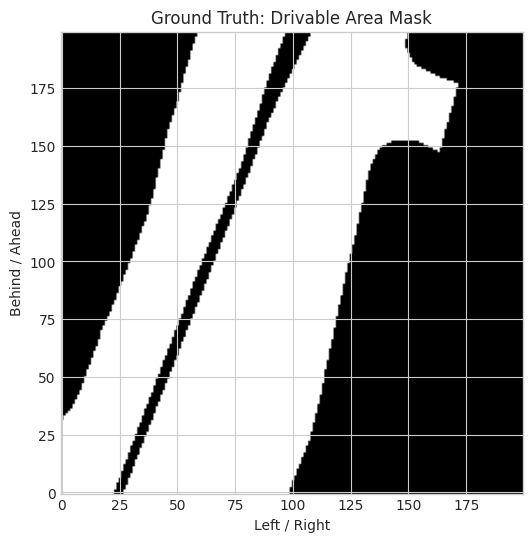

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from pyquaternion import Quaternion
from nuscenes.map_expansion.map_api import NuScenesMap

# 1. Get the current scene and determine which city it was recorded in
my_scene = nusc.scene[0]
log = nusc.get('log', my_scene['log_token'])
location = log['location']

print(f"Loading map for: {location}")

# 2. Initialize the HD Map for this specific location
nusc_map = NuScenesMap(dataroot='./data/sets/nuscenes', map_name=location)

# 3. Get the ego vehicle's pose for the first sample
first_sample_token = my_scene['first_sample_token']
sample = nusc.get('sample', first_sample_token)
cam_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
ego_pose = nusc.get('ego_pose', cam_data['ego_pose_token'])

# 4. Define the BEV patch dimensions (in meters)
# This creates a 40x40 meter grid centered on the car
patch_box = (ego_pose['translation'][0], ego_pose['translation'][1], 40, 40)

# Calculate the vehicle's yaw so the map rotates to align with the camera direction
patch_angle = Quaternion(ego_pose['rotation']).yaw_pitch_roll[0]

# 5. Rasterize the 'drivable_area' polygon layer into a 2D pixel grid
# canvas_size=(200, 200) converts the 40x40m physical space into a 200x200 pixel mask
mask = nusc_map.get_map_mask(
    patch_box=patch_box,
    patch_angle=patch_angle,
    layer_names=['drivable_area'],
    canvas_size=(200, 200)
)

# 6. Visualize the ground truth label
plt.figure(figsize=(6, 6))
# mask[0] isolates the drivable_area layer. 
# The ego vehicle is located exactly in the center, facing "up".
plt.imshow(mask[0], origin='lower', cmap='gray')
plt.title('Ground Truth: Drivable Area Mask')
plt.xlabel('Left / Right')
plt.ylabel('Behind / Ahead')
plt.show()

In [5]:
# 1. Download the map expansion pack
!wget https://www.nuscenes.org/data/nuScenes-map-expansion-v1.3.zip -O ./data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip

# 2. Unzip it directly into the existing 'maps' directory
# (Using -q for quiet output and -o to silently overwrite, preventing prompt hangs in Jupyter)
!unzip -q -o ./data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip -d ./data/sets/nuscenes/maps/

# 3. Delete the zip archive to save space
!rm ./data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip

--2026-02-22 11:52:59--  https://www.nuscenes.org/data/nuScenes-map-expansion-v1.3.zip
Resolving www.nuscenes.org (www.nuscenes.org)... 108.158.251.16, 108.158.251.89, 108.158.251.86, ...
Connecting to www.nuscenes.org (www.nuscenes.org)|108.158.251.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6427 (6.3K) [text/html]
Saving to: ‘./data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip’

./data/sets/nuscene 100%[===================>]   6.28K  --.-KB/s    in 0s      

2026-02-22 11:53:01 (1.79 GB/s) - ‘./data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip’ saved [6427/6427]

/bin/bash: line 1: unzip: command not found


In [4]:
'''import zipfile
import os

# Delete the fake 6KB HTML file if it's still there
fake_file = './data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip'
if os.path.exists(fake_file) and os.path.getsize(fake_file) < 10000:
    os.remove(fake_file)
    print("Deleted the 6KB HTML file. Please upload the real zip file via Jupyter.")

# Once the real file is uploaded, extract it
zip_path = './data/sets/nuscenes/nuScenes-map-expansion-v1.3.zip'
extract_path = './data/sets/nuscenes/maps/'

if os.path.exists(zip_path) and os.path.getsize(zip_path) > 1000000: 
    print("Extracting map expansion pack...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Maps extracted successfully!")
else:
    print("⏳ Waiting for the real zip file to be uploaded to your directory...")'''

Extracting map expansion pack...
✅ Maps extracted successfully!


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from nuscenes.utils.data_classes import RadarPointCloud, LidarPointCloud
from nuscenes.map_expansion.map_api import NuScenesMap
from pyquaternion import Quaternion

class NuScenesFusionDataset(Dataset):
    def __init__(self, nusc_env, scene_list, max_lidar_points=8192):
        self.nusc = nusc_env
        self.samples = []
        self.max_lidar_points = max_lidar_points
        
        # 1. Flatten all samples
        for scene in scene_list:
            current_token = scene['first_sample_token']
            while current_token != '':
                sample = self.nusc.get('sample', current_token)
                self.samples.append(sample)
                current_token = sample['next']
                
        # 2. Image transforms (Aggressive downsampling for 4GB VRAM)
        self.img_transform = transforms.Compose([
            transforms.Resize((224, 400)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # 3. Pre-load HD Maps
        print("Pre-loading HD Maps into memory...")
        locations = ['boston-seaport', 'singapore-onenorth', 'singapore-hollandvillage', 'singapore-queenstown']
        self.nusc_maps = {loc: NuScenesMap(dataroot=self.nusc.dataroot, map_name=loc) for loc in locations}
        print("Maps loaded successfully!")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # --- 1. Camera Image (Input X1) ---
        cam_token = sample['data']['CAM_FRONT']
        cam_data = self.nusc.get('sample_data', cam_token)
        cam_path = self.nusc.get_sample_data_path(cam_token)
        image = Image.open(cam_path).convert('RGB')
        img_tensor = self.img_transform(image)
        
        # --- 2. RADAR Data (Input X2) ---
        radar_token = sample['data']['RADAR_FRONT']
        radar_path = self.nusc.get_sample_data_path(radar_token)
        radar_pc = RadarPointCloud.from_file(radar_path)
        radar_features = radar_pc.points[[0, 1, 2, 8, 9], :].T
        radar_tensor = torch.tensor(radar_features, dtype=torch.float32)
        
        # --- 3. LiDAR Data (Input X3) ---
        lidar_token = sample['data']['LIDAR_TOP']
        lidar_path = self.nusc.get_sample_data_path(lidar_token)
        lidar_pc = LidarPointCloud.from_file(lidar_path)
        
        # Extract x, y, z, and intensity (Shape becomes N x 4)
        lidar_features = lidar_pc.points.T 
        
        # VRAM Safeguard: Random Point Sampling
        num_points = lidar_features.shape[0]
        if num_points >= self.max_lidar_points:
            indices = np.random.choice(num_points, self.max_lidar_points, replace=False)
        else:
            # Pad with duplicates if a sweep happens to have fewer points
            indices = np.random.choice(num_points, self.max_lidar_points, replace=True)
            
        lidar_tensor = torch.tensor(lidar_features[indices, :], dtype=torch.float32)
        
        # --- 4. Semantic BEV Map (Ground Truth Y) ---
        scene = self.nusc.get('scene', sample['scene_token'])
        log = self.nusc.get('log', scene['log_token'])
        location = log['location']
        
        ego_pose = self.nusc.get('ego_pose', cam_data['ego_pose_token'])
        patch_box = (ego_pose['translation'][0], ego_pose['translation'][1], 40, 40)
        patch_angle = Quaternion(ego_pose['rotation']).yaw_pitch_roll[0]
        
        mask = self.nusc_maps[location].get_map_mask(
            patch_box=patch_box,
            patch_angle=patch_angle,
            layer_names=['drivable_area'],
            canvas_size=(200, 200)
        )
        mask_tensor = torch.tensor(mask[0], dtype=torch.float32).unsqueeze(0)
        
        return {
            'image': img_tensor,
            'radar': radar_tensor,
            'lidar': lidar_tensor,  # <-- Added LiDAR output
            'label_mask': mask_tensor,
            'sample_token': sample['token']
        }

In [6]:
fusion_dataset = NuScenesFusionDataset(nusc, nusc.scene[:3])
train_loader = DataLoader(fusion_dataset, batch_size=1, shuffle=True, num_workers=0)

for batch in train_loader:
    print("✅ Full Multimodal Batch Loaded!")
    print("-" * 35)
    print(f"📷 Image Input Shape:  {batch['image'].shape}")
    print(f"🔦 LiDAR Input Shape:  {batch['lidar'].shape} -> [Batch, Points, x,y,z,intensity]")
    print(f"📡 RADAR Input Shape:  {batch['radar'].shape} -> [Batch, Points, x,y,z,vx,vy]")
    print(f"🗺️ Target Mask Shape: {batch['label_mask'].shape}")
    break

Pre-loading HD Maps into memory...
Maps loaded successfully!
✅ Full Multimodal Batch Loaded!
-----------------------------------
📷 Image Input Shape:  torch.Size([1, 3, 224, 400])
🔦 LiDAR Input Shape:  torch.Size([1, 8192, 4]) -> [Batch, Points, x,y,z,intensity]
📡 RADAR Input Shape:  torch.Size([1, 78, 5]) -> [Batch, Points, x,y,z,vx,vy]
🗺️ Target Mask Shape: torch.Size([1, 1, 200, 200])


In [7]:
import torch.nn as nn
import torchvision.models as models

class PointNetExtractor(nn.Module):
    """Extracts features from an unordered point cloud (N points, C channels)"""
    def __init__(self, in_channels, out_features):
        super().__init__()
        # 1D Convolutions act as shared Multi-Layer Perceptrons (MLPs) across all points
        self.mlp = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, out_features, kernel_size=1),
            nn.BatchNorm1d(out_features),
            nn.ReLU()
        )
        
    def forward(self, x):
        # PyTorch Conv1d expects shape: [Batch, Channels, Points]
        x = x.transpose(1, 2) 
        x = self.mlp(x)
        # Global Max Pooling collapses the points into a single feature vector
        x = torch.max(x, dim=2, keepdim=False)[0] 
        return x

class BEVFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. Image Backbone (MobileNetV2 - Fast and VRAM friendly)
        mobilenet = models.mobilenet_v2(pretrained=True)
        self.image_backbone = nn.Sequential(*list(mobilenet.features.children()))
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1)) # Output: 1280 features
        
        # 2. Point Cloud Backbones
        self.lidar_net = PointNetExtractor(in_channels=4, out_features=128)
        self.radar_net = PointNetExtractor(in_channels=5, out_features=64)
        
        # 3. Fusion Layer
        # Total concatenated features: 1280 (Image) + 128 (LiDAR) + 64 (Radar) = 1472
        self.fc = nn.Linear(1472, 256 * 5 * 5)
        
        # 4. BEV Decoder (Upsampling back to 200x200)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # -> 10x10
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # -> 20x20
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # -> 40x40
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=5, stride=5, padding=0),    # -> 200x200
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid() # Outputs probabilities between 0 (Obstacle) and 1 (Drivable Road)
        )

    def forward(self, image, lidar, radar):
        # Extract features
        img_feat = self.image_pool(self.image_backbone(image)).flatten(1)
        lidar_feat = self.lidar_net(lidar)
        radar_feat = self.radar_net(radar)
        
        # Concatenate (Fuse)
        fused = torch.cat([img_feat, lidar_feat, radar_feat], dim=1)
        
        # Reshape for 2D Convolutions
        x = self.fc(fused).view(-1, 256, 5, 5)
        
        # Decode to BEV Mask
        out = self.decoder(x)
        return out

In [8]:
# 1. Initialize the model
model = BEVFusionModel()

# 2. Extract the inputs from the batch you just loaded
img_input = batch['image']
lidar_input = batch['lidar']
radar_input = batch['radar']

# 3. Pass data through the network
print("Passing data through the model...")
predictions = model(img_input, lidar_input, radar_input)

# 4. Verify the output
print("✅ Forward Pass Successful!")
print("-" * 35)
print(f"Network Output Shape: {predictions.shape} -> [Batch, Channel, Height, Width]")

/home/akashpq/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/akashpq/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Passing data through the model...
✅ Forward Pass Successful!
-----------------------------------
Network Output Shape: torch.Size([1, 1, 200, 200]) -> [Batch, Channel, Height, Width]


In [10]:
'''import torch

# 1. Check if CUDA (NVIDIA GPU support) is available
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    # 2. Get the number of GPUs
    print(f"GPU Count: {torch.cuda.device_count()}")
    
    # 3. Get the name of the current GPU
    current_device = torch.cuda.current_device()
    print(f"Current GPU Index: {current_device}")
    print(f"GPU Name: {torch.cuda.get_device_name(current_device)}")
    
    # 4. Memory Usage (in GB)
    allocated = torch.cuda.memory_allocated(0) / (1024**3)
    cached = torch.cuda.memory_reserved(0) / (1024**3)
    print(f"Allocated Memory: {allocated:.2f} GB")
    print(f"Cached Memory: {cached:.2f} GB")
else:
    print("PyTorch is running on CPU.")'''

'import torch\n\n# 1. Check if CUDA (NVIDIA GPU support) is available\nprint(f"CUDA available: {torch.cuda.is_available()}")\n\nif torch.cuda.is_available():\n    # 2. Get the number of GPUs\n    print(f"GPU Count: {torch.cuda.device_count()}")\n    \n    # 3. Get the name of the current GPU\n    current_device = torch.cuda.current_device()\n    print(f"Current GPU Index: {current_device}")\n    print(f"GPU Name: {torch.cuda.get_device_name(current_device)}")\n    \n    # 4. Memory Usage (in GB)\n    allocated = torch.cuda.memory_allocated(0) / (1024**3)\n    cached = torch.cuda.memory_reserved(0) / (1024**3)\n    print(f"Allocated Memory: {allocated:.2f} GB")\n    print(f"Cached Memory: {cached:.2f} GB")\nelse:\n    print("PyTorch is running on CPU.")'

In [11]:
'''import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

# 1. Hardware Configuration
# Transfer the model from the CPU to your RTX 3050
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
model = model.to(device)

# 2. Loss Function and Optimizer
# BCELoss compares the model's probability map [0 to 1] against the binary ground truth mask
criterion = torch.nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Initialize the GradScaler for Mixed Precision training
scaler = GradScaler()

# 3. Training Loop Setup
epochs = 1
model.train() # Set model to training mode (enables gradients and BatchNorm updates)

print("Starting training loop...")
print("-" * 35)

for epoch in range(epochs):
    for batch_idx, batch in enumerate(train_loader):
        
        # A. Move all input and target tensors to the GPU
        images = batch['image'].to(device)
        lidar = batch['lidar'].to(device)
        radar = batch['radar'].to(device)
        targets = batch['label_mask'].to(device)
        
        # B. Clear old gradients from the previous step
        optimizer.zero_grad()
        
        # C. Forward Pass with Automatic Mixed Precision
        with autocast():
            predictions = model(images, lidar, radar)
            loss = criterion(predictions, targets)
            
        # D. Backward Pass (Calculate Gradients)
        # Scaler prevents underflow issues when working in FP16
        scaler.scale(loss).backward()
        
        # E. Optimizer Step (Update Model Weights)
        scaler.step(optimizer)
        scaler.update()
        
        print(f"Epoch [{epoch+1}/{epochs}] | Batch: {batch_idx} | BCE Loss: {loss.item():.4f}")
        
        # Break after the first batch just to verify the loop runs without crashing
        break 
        
print("-" * 35)
print("✅ GPU Training Step Successful!")'''

Training on: cuda


/tmp/ipykernel_5483/3928605764.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_5483/3928605764.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Starting training loop...
-----------------------------------


RuntimeError: torch.nn.functional.binary_cross_entropy and torch.nn.BCELoss are unsafe to autocast.
Many models use a sigmoid layer right before the binary cross entropy layer.
In this case, combine the two layers using torch.nn.functional.binary_cross_entropy_with_logits
or torch.nn.BCEWithLogitsLoss.  binary_cross_entropy_with_logits and BCEWithLogits are
safe to autocast.

In [12]:
class BEVFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. Image Backbone
        mobilenet = models.mobilenet_v2(pretrained=True)
        self.image_backbone = nn.Sequential(*list(mobilenet.features.children()))
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1)) 
        
        # 2. Point Cloud Backbones
        self.lidar_net = PointNetExtractor(in_channels=4, out_features=128)
        self.radar_net = PointNetExtractor(in_channels=5, out_features=64)
        
        # 3. Fusion Layer
        self.fc = nn.Linear(1472, 256 * 5 * 5)
        
        # 4. BEV Decoder (REMOVED SIGMOID)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=5, stride=5, padding=0),    
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
            # No Sigmoid here! The model now outputs raw logits.
        )

    def forward(self, image, lidar, radar):
        img_feat = self.image_pool(self.image_backbone(image)).flatten(1)
        lidar_feat = self.lidar_net(lidar)
        radar_feat = self.radar_net(radar)
        fused = torch.cat([img_feat, lidar_feat, radar_feat], dim=1)
        x = self.fc(fused).view(-1, 256, 5, 5)
        out = self.decoder(x)
        return out

# Re-initialize the updated model
model = BEVFusionModel()

/home/akashpq/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/akashpq/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
import torch.optim as optim
from torch.amp import autocast, GradScaler # Updated import

# 1. Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
model = model.to(device)

# 2. Loss Function and Optimizer
# BCEWithLogitsLoss safely handles the Sigmoid operation internally
criterion = torch.nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Updated GradScaler syntax for modern PyTorch
scaler = GradScaler('cuda') 

# 3. Training Loop Setup
epochs = 1
model.train() 

print("Starting training loop...")
print("-" * 35)

for epoch in range(epochs):
    for batch_idx, batch in enumerate(train_loader):
        
        images = batch['image'].to(device)
        lidar = batch['lidar'].to(device)
        radar = batch['radar'].to(device)
        targets = batch['label_mask'].to(device)
        
        optimizer.zero_grad()
        
        # Updated autocast syntax
        with autocast('cuda'):
            predictions = model(images, lidar, radar)
            loss = criterion(predictions, targets)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        print(f"Epoch [{epoch+1}/{epochs}] | Batch: {batch_idx} | BCE Loss: {loss.item():.4f}")
        
        # Break after the first batch to verify
        break 
        
print("-" * 35)
print("✅ GPU Training Step Successful!")

Training on: cuda
Starting training loop...
-----------------------------------
Epoch [1/1] | Batch: 0 | BCE Loss: 0.6957
-----------------------------------
✅ GPU Training Step Successful!


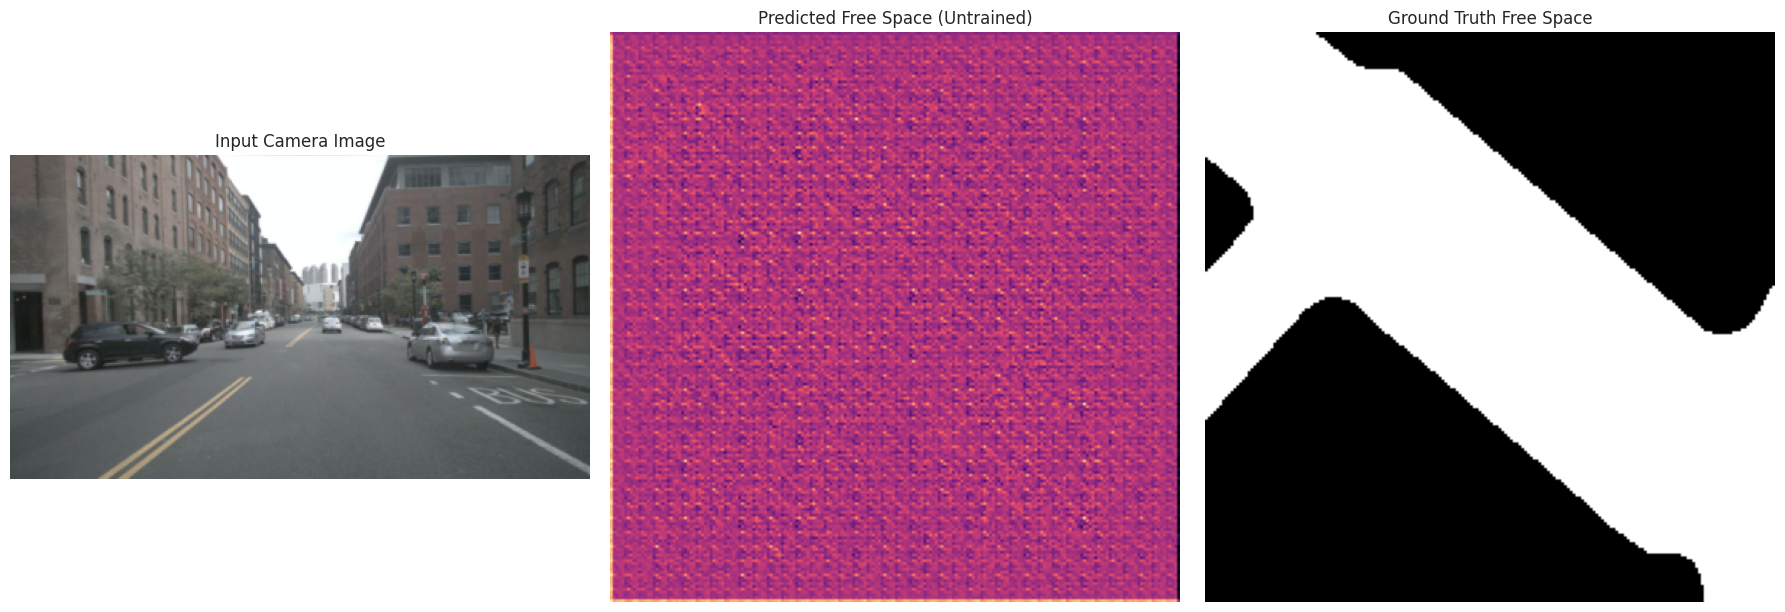

In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Put the model in evaluation mode (disables dropout and batch norm updates)
model.eval()

# 2. Run a forward pass without calculating gradients to save memory
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        # Pass the same inputs we just used in the training loop
        raw_logits = model(images, lidar, radar)
        
    # 3. Apply Sigmoid to convert raw logits back into probabilities (0.0 to 1.0)
    probabilities = torch.sigmoid(raw_logits)
    
# 4. Move data back to the CPU and convert to NumPy for plotting
# Squeeze out the batch and channel dimensions: [1, 1, 200, 200] -> [200, 200]
pred_mask = probabilities.squeeze().cpu().numpy()
true_mask = targets.squeeze().cpu().numpy()

# 5. Un-normalize the camera image for human viewing
# We reverse the ImageNet normalization applied in the dataset class
img_vis = images.squeeze().cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_vis = np.clip((img_vis * std) + mean, 0, 1)

# 6. Plot the results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_vis)
axes[0].set_title('Input Camera Image')
axes[0].axis('off')

# Using 'magma' colormap so higher probabilities appear brighter
axes[1].imshow(pred_mask, cmap='magma', origin='lower')
axes[1].set_title('Predicted Free Space (Untrained)')
axes[1].axis('off')

axes[2].imshow(true_mask, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth Free Space')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Starting 50-Epoch Overfit Test...
-----------------------------------
Epoch [10/400] | BCE Loss: 0.0005
Epoch [20/400] | BCE Loss: 0.0004
Epoch [30/400] | BCE Loss: 0.0004
Epoch [40/400] | BCE Loss: 0.0003
Epoch [50/400] | BCE Loss: 0.0003
Epoch [60/400] | BCE Loss: 0.0003
Epoch [70/400] | BCE Loss: 0.0003
Epoch [80/400] | BCE Loss: 0.0002
Epoch [90/400] | BCE Loss: 0.0002
Epoch [100/400] | BCE Loss: 0.0002
Epoch [110/400] | BCE Loss: 0.0002
Epoch [120/400] | BCE Loss: 0.0002
Epoch [130/400] | BCE Loss: 0.0002
Epoch [140/400] | BCE Loss: 0.0002
Epoch [150/400] | BCE Loss: 0.0002
Epoch [160/400] | BCE Loss: 0.0001
Epoch [170/400] | BCE Loss: 0.0001
Epoch [180/400] | BCE Loss: 0.0001
Epoch [190/400] | BCE Loss: 0.0001
Epoch [200/400] | BCE Loss: 0.0001
Epoch [210/400] | BCE Loss: 0.0001
Epoch [220/400] | BCE Loss: 0.0001
Epoch [230/400] | BCE Loss: 0.0001
Epoch [240/400] | BCE Loss: 0.0001
Epoch [250/400] | BCE Loss: 0.0001
Epoch [260/400] | BCE Loss: 0.0001
Epoch [270/400] | BCE Loss: 0

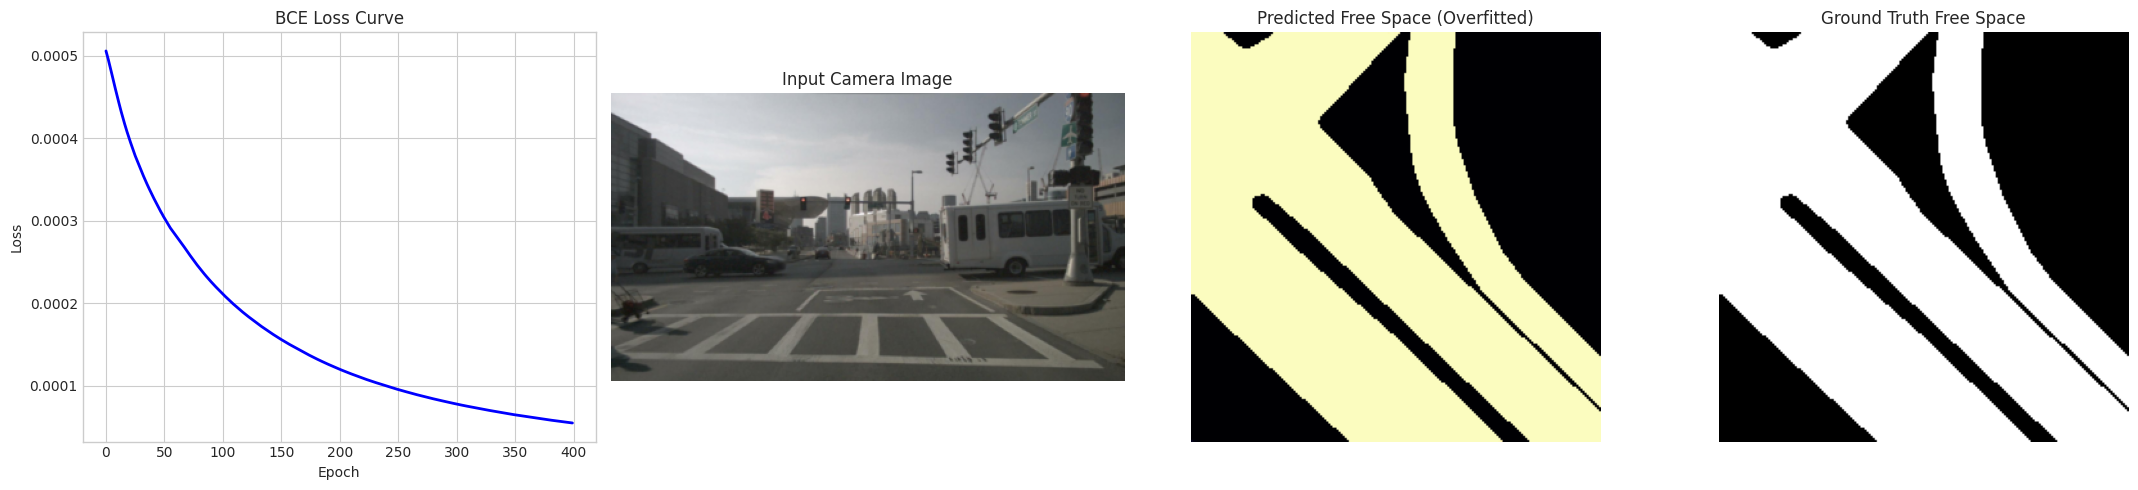

In [16]:
import matplotlib.pyplot as plt

# 1. Grab exactly ONE batch to memorize
batch = next(iter(train_loader))
images = batch['image'].to(device)
lidar = batch['lidar'].to(device)
radar = batch['radar'].to(device)
targets = batch['label_mask'].to(device)

# 2. Setup training parameters
epochs = 400
model.train()
loss_history = []

print("Starting 50-Epoch Overfit Test...")
print("-" * 35)

for epoch in range(epochs):
    optimizer.zero_grad()
    
    with torch.amp.autocast('cuda'):
        predictions = model(images, lidar, radar)
        loss = criterion(predictions, targets)
        
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    
    loss_history.append(loss.item())
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | BCE Loss: {loss.item():.4f}")

print("✅ Overfit Test Complete!")

# --- VISUALIZATION PHASE ---
model.eval()
with torch.no_grad():
    with torch.amp.autocast('cuda'):
        raw_logits = model(images, lidar, radar)
    probabilities = torch.sigmoid(raw_logits)

# Convert to numpy for plotting
pred_mask = probabilities.squeeze().cpu().numpy()
true_mask = targets.squeeze().cpu().numpy()

# Un-normalize camera image
img_vis = images.squeeze().cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_vis = np.clip((img_vis * std) + mean, 0, 1)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(loss_history, color='blue', linewidth=2)
axes[0].set_title('BCE Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].imshow(img_vis)
axes[1].set_title('Input Camera Image')
axes[1].axis('off')

axes[2].imshow(pred_mask, cmap='magma', origin='lower')
axes[2].set_title('Predicted Free Space (Overfitted)')
axes[2].axis('off')

axes[3].imshow(true_mask, cmap='gray', origin='lower')
axes[3].set_title('Ground Truth Free Space')
axes[3].axis('off')

plt.tight_layout()
plt.show()